                                                                Decision Tree

In [3]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [4]:
# Load dataset
df=pd.read_excel("heart_disease (1).xlsx")
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [5]:
df.columns=df.columns.str.strip()
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 22 columns):
 #   Column                                                                                                                                                                                                                                                                                        Non-Null Count  Dtype
---  ------                                                                                                                                                                                                                                                                                        --------------  -----
 0   age_chol                                                                                                                                                                                                                                                                  

,age_chol,age_cp,age_exang,age_fbs,age_num,age_oldpeak,age_restecg,age_slope,age_thal,age_thalch,...,"Age in years_Gender ; Male - 1, Female -0",Age in years_Resting blood pressure,Age in years_ST depression induced by exercise relative to rest,Age in years_Thal,Age in years_cholesterol measure,"Age in years_ecg observation at resting condition, -- Value 0: normal\n -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)\n -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria",Age in years_exercise induced angina,Age in years_maximum heart rate achieved,"Age in years_target [0=no heart disease; 1,2,3,4 = stages of heart disease ]",Age in years_the slope of the peak exercise ST segment
count,12,12,12,12,12,12,12,12,12,12,...,12,12,12,12,12,12,12,12,12,12
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
freq,11,11,11,11,11,11,11,11,11,11,...,11,11,11,11,11,11,11,11,11,11


In [10]:
# Convert everything possible to numeric
df=df.apply(lambda x: pd.to_numeric(x,errors='ignore'))
df=pd.get_dummies(df, drop_first=True)

In [11]:
df=df.fillna(df.mean())

In [13]:
numeric_df = df.select_dtypes(include=[np.number])

print("Numeric columns:", numeric_df.columns)
print(numeric_df.head())


Numeric columns: Index([], dtype='object')
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [14]:
print(numeric_df.shape)

(12, 0)


In [38]:
# Select numeric columns
numeric_df=df.select_dtypes(include=[np.number])
numeric_df=numeric_df.dropna(axis=1, how='all')
numeric_df=numeric_df.fillna(numeric_df.mean())

# Check if numeric data exists
if numeric_df.shape[1]==0:
    print("No numeric data available")

else:
    print("Numeric columns:", numeric_df.columns)
    for col in numeric_df.columns:
        plt.figure()
        sns.histplot(numeric_df[col], kde=True)
        plt.title(col)
        plt.show()

# Correlation heatmap
    if numeric_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
        plt.title("Correlation Matrix")
        plt.show()
    else:
        print("Not enough columns for correlation")

No numeric data available


In [39]:
X=df.iloc[:, :-1]
y=df.iloc[:, -1]

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
    X, y,test_size=0.2,random_state=42)

In [32]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Accuracy: 0.6666666666666666

Classification Report:
               precision    recall  f1-score   support

       False       0.67      1.00      0.80         2
        True       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


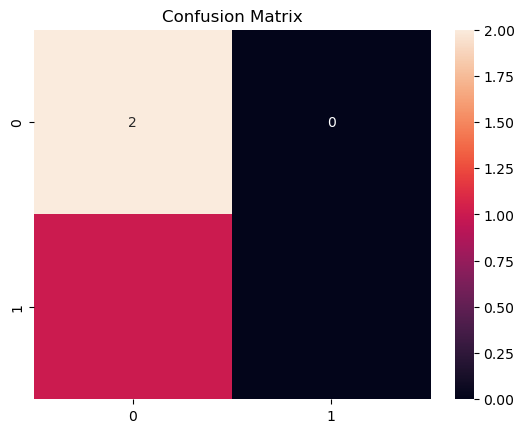

In [33]:
y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

print("\nClassification Report:\n",classification_report(y_test,y_pred))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [34]:
try:
    y_prob=model.predict_proba(X_test)[:,1]
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
except:
    print("ROC-AUC not applicable for this dataset")

ROC-AUC not applicable for this dataset


In [35]:
params={
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']}
grid=GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [36]:
best_model=grid.best_estimator_

y_pred_best=best_model.predict(X_test)

print("Improved Accuracy:",accuracy_score(y_test, y_pred_best))

Improved Accuracy: 0.6666666666666666


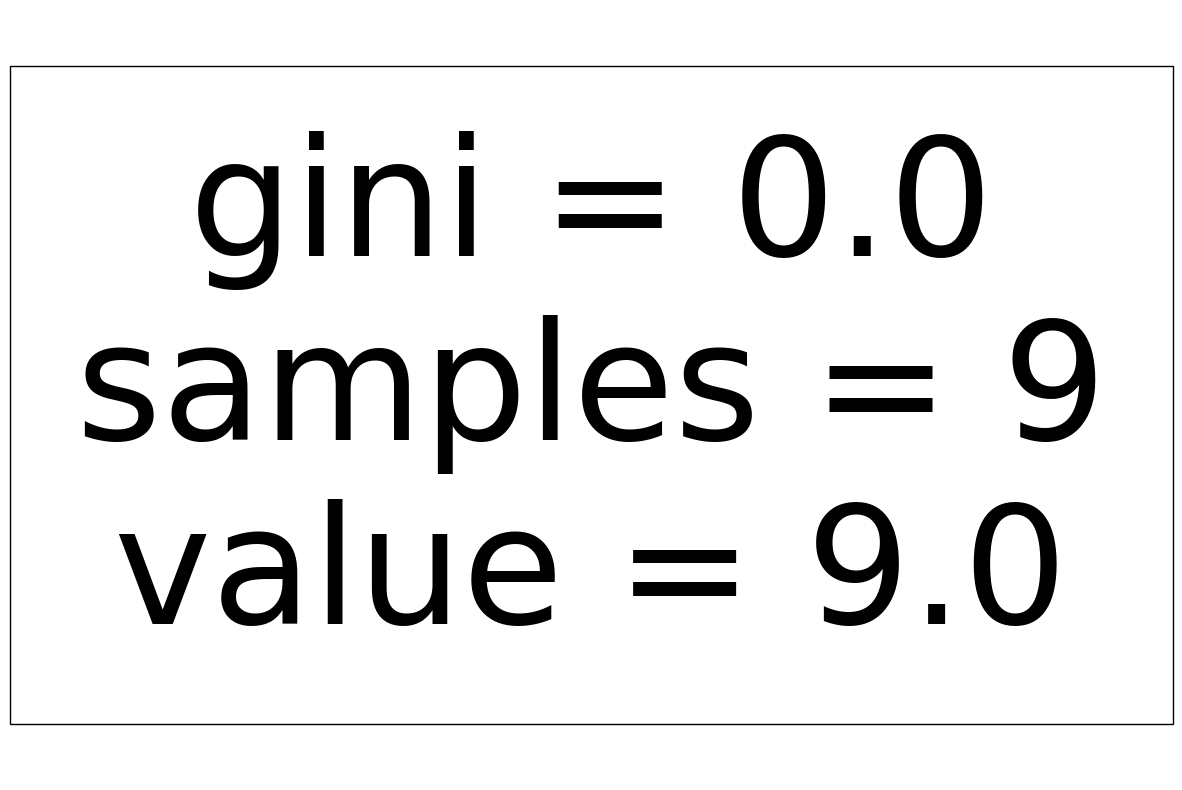

In [37]:
plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True, feature_names=X.columns)
plt.show()

Interview Questions

1) Decision Trees have several hyperparameters that control how the tree grows and performs.

Important Hyperparameters:
- max_depth = Maximum depth of the tree
- min_samples_split = Minimum number of samples required to split a node
- min_samples_leaf = Minimum samples required in a leaf node
- criterion = Measures quality of split
- max_features = Number of features considered at each split


2) Label Encoding:
        converts categorical text into integer labels (0, 1, 2) and is best for ordinal data (e.g., Small, Medium, High), but it can falsely imply numerical relationships.
